In [1]:
#Cell 0:Environment Setup
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 1: SETUP AND  DATA DOWNLOAD
import os
import urllib.request
import zipfile
import wfdb
import numpy as np
import torch
import torch.nn as nn
import random
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. Setting Seed for Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# --- 2. Dual-Method of Data Downloading ---
URL = "https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip"
ZIP_PATH = "mitbih_dataset.zip"
EXTRACT_DIR = "data"

# Defined the two possible paths depending on which method works
DATA_PATH_ZIP = os.path.join(EXTRACT_DIR, "mit-bih-arrhythmia-database-1.0.0")
DATA_PATH_WFDB = "data/mitdb"

download_success = False

print("Attempting Method 1: Direct ZIP download (urllib)...")
try:
    if not os.path.exists(ZIP_PATH) and not os.path.exists(DATA_PATH_ZIP):
        urllib.request.urlretrieve(URL, ZIP_PATH)
    
    # Checking did we get a real ZIP file or did the server block us with an HTML page (common with PhysioNet)
    if os.path.exists(DATA_PATH_ZIP):
        download_success = True
        DATA_PATH = DATA_PATH_ZIP
        print("Dataset already extracted via ZIP.")
    elif zipfile.is_zipfile(ZIP_PATH):
        print("Extracting ZIP dataset...")
        with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        download_success = True
        DATA_PATH = DATA_PATH_ZIP
        print("Method 1 Successful! ZIP extracted.")
    else:
        print("Warning: Downloaded file is not a valid ZIP (likely blocked by PhysioNet).")
        
except Exception as e:
    print(f"Direct download failed: {e}")

# --- Method 2 for download ---
if not download_success:
    print("\n--- Method 1 Failed. Initiating Fallback Method 2: Official WFDB API ---")
    print("This ensures 100% reproducibility without authentication/403 errors.")
    
    if not os.path.exists(DATA_PATH_WFDB):
        os.makedirs(DATA_PATH_WFDB)
        print("Downloading dataset using wfdb...")
        wfdb.dl_database("mitdb", dl_dir=DATA_PATH_WFDB)
    
    DATA_PATH = DATA_PATH_WFDB
    
    # The WFDB method doesn't download the 'RECORDS' list file by default in the same way, so we can generate it here so Cell 2 works without modification.
    records = wfdb.get_record_list('mitdb')
    with open(os.path.join(DATA_PATH, 'RECORDS'), 'w') as f:
        for r in records:
            f.write(f"{r}\n")
            
    print("Method 2 Successful! WFDB download complete.")

print(f"\nFinal Data Path set to: {DATA_PATH}")

Using device: cpu

Attempting Method 1: Direct ZIP download (urllib)...
Dataset already extracted via ZIP.

Final Data Path set to: data\mit-bih-arrhythmia-database-1.0.0


In [3]:
# CELL 1.5: DATA INTEGRITY VERIFICATION
print("--- Verifying Dataset Integrity ---")
sample_record_path = os.path.join(DATA_PATH, '100')

record = wfdb.rdrecord(sample_record_path)
annotation = wfdb.rdann(sample_record_path, 'atr')

print(f"Signal shape: {record.p_signal.shape} (Samples, Channels)")
print(f"Sampling frequency: {record.fs} Hz")
print(f"First 10 annotation symbols: {annotation.symbol[:10]}")

--- Verifying Dataset Integrity ---
Signal shape: (650000, 2) (Samples, Channels)
Sampling frequency: 360 Hz
First 10 annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [4]:
# CELL 2: BUILD SEQUENCE WINDOWS & PREPROCESS
import os
import wfdb
import numpy as np

# Justification: 360Hz sampling rate * ~0.83 seconds = 300 samples to capture a full P-QRS-T heartbeat.
WINDOW_SIZE = 300  
HALF_WINDOW = WINDOW_SIZE // 2

records_file = os.path.join(DATA_PATH, 'RECORDS')
with open(records_file, 'r') as f:
    patient_ids = [line.strip() for line in f]

X, y, groups = [], [], []

print("Extracting and Normalizing windows... (This takes a moment)")
print("Task: Binary classification between Normal (N) and selected abnormalities (L, R, V, /). Other classes discarded.")

for pid in patient_ids:
    record_path = os.path.join(DATA_PATH, pid)
    try:
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal[:, 0] # Use primary lead (Lead II)
        annotation = wfdb.rdann(record_path, 'atr')
    except FileNotFoundError:
        continue
        
    for sample_idx, symbol in zip(annotation.sample, annotation.symbol):
        # Boundary check to prevent index errors
        if sample_idx < HALF_WINDOW or sample_idx > len(signal) - HALF_WINDOW:
            continue
            
        # Keep Normal ('N') and specific Arrhythmias ('L', 'R', 'V', '/')
        if symbol in ['N', 'L', 'R', 'V', '/']:
            window = signal[sample_idx - HALF_WINDOW : sample_idx + HALF_WINDOW]
            
            # Prevents model from learning patient-specific amplitude scales
            window = (window - np.mean(window)) / (np.std(window) + 1e-8)
            
            label = 0 if symbol == 'N' else 1 # 0: Normal, 1: Arrhythmia
            
            X.append(window)
            y.append(label)
            groups.append(int(pid)) # Track patient ID for leakage prevention

X_all = np.array(X, dtype=np.float32)
y_all = np.array(y, dtype=np.int64)
groups_all = np.array(groups)

print("\n--- Extraction Complete ---")
print(f"Total sequences extracted: {len(X_all)}")
print(f"Shape of X: {X_all.shape}")

# --- Class Imbalance Check ---
unique, counts = np.unique(y_all, return_counts=True)
class_distribution = dict(zip(unique, counts))
print(f"Class Distribution: {class_distribution}")
print(f"Normal (0): {counts[0]/len(y_all)*100:.2f}% | Arrhythmia (1): {counts[1]/len(y_all)*100:.2f}%")

Extracting and Normalizing windows... (This takes a moment)
Task: Binary classification between Normal (N) and selected abnormalities (L, R, V, /). Other classes discarded.

--- Extraction Complete ---
Total sequences extracted: 104495
Shape of X: (104495, 300)
Class Distribution: {np.int64(0): np.int64(75017), np.int64(1): np.int64(29478)}
Normal (0): 71.79% | Arrhythmia (1): 28.21%


In [5]:
# CELL 3: LEAKAGE-FREE SPLIT & TENSOR CONVERSION
from sklearn.model_selection import GroupShuffleSplit
import torch
from torch.utils.data import TensorDataset, DataLoader

print("--- Executing Patient-Wise Group Split ---")

# 1. Split by Patient ID to prevent data leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

# 2. Convert to Tensors
# Features: (Batch, 1 Channel, 300 Time Steps) for 1D-CNN
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

# Labels: BCEWithLogitsLoss requires float32 and shape (Batch, 1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# 3. Optimize DataLoaders
BATCH_SIZE = 128
use_pin_memory = (device.type == "cuda")

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor), 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    pin_memory=use_pin_memory
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor), 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    pin_memory=use_pin_memory
)

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"Input Tensor Shape: {X_train_tensor.shape} -> (Batch, Channels, Sequence_Length)")
print(f"Target Tensor Shape: {y_train_tensor.shape} -> (Batch, 1)")

--- Executing Patient-Wise Group Split ---
Train samples: 83327 | Test samples: 21168
Input Tensor Shape: torch.Size([83327, 1, 300]) -> (Batch, Channels, Sequence_Length)
Target Tensor Shape: torch.Size([83327, 1]) -> (Batch, 1)


Linear Baseline Architecture Initialization Complete:
 LogisticRegressionBaseline(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

--- Training Pure Linear Model (5 Epochs) | pos_weight=2.05 ---
  Epoch 1 | train_loss= 0.4540 acc= 0.8910 | val_loss= 0.6837 acc= 0.7774
  Epoch 2 | train_loss= 0.3607 acc= 0.9216 | val_loss= 0.7386 acc= 0.7705
  Epoch 3 | train_loss= 0.3330 acc= 0.9270 | val_loss= 0.7407 acc= 0.7684
  Epoch 4 | train_loss= 0.3161 acc= 0.9288 | val_loss= 0.7830 acc= 0.7584
  Epoch 5 | train_loss= 0.3052 acc= 0.9288 | val_loss= 0.7983 acc= 0.7525

--- Final Evaluating Linear Baseline ---

Linear Classification Report:
                precision    recall  f1-score   support

    Normal (0)       0.98      0.74      0.84     18990
Arrhythmia (1)       0.28      0.88      0.42      2178

      accuracy                           0.75     21168
     macro avg       0.63      0.81      0.63     21168
  weighted avg      

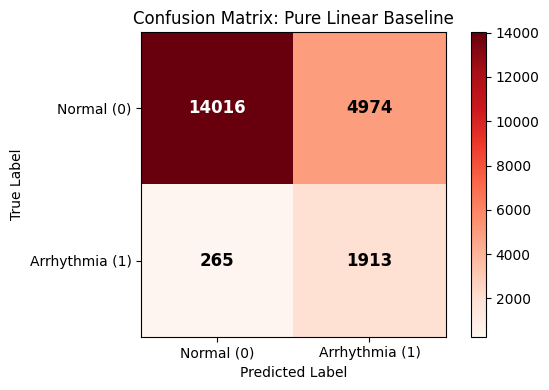

In [6]:
# CELL 4: PURE LINEAR BASELINE (LOGISTIC REGRESSION)
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- REUSABLE PLOTTING FUNCTION (Used in generating every matrix) ---
def plot_beautiful_cm(y_true, y_pred, model_name, cmap=plt.cm.Blues):
    cm = confusion_matrix(y_true, y_pred)
    class_names = ['Normal (0)', 'Arrhythmia (1)']

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap) # <-- Now uses your color choice!
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names, yticklabels=class_names,
           title=f'Confusion Matrix: {model_name}',
           ylabel='True Label', xlabel='Predicted Label')

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", rotation_mode="anchor")

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=12, fontweight='bold')

    fig.tight_layout()
    plt.show()

# --- MODEL DEFINITION ---
class LogisticRegressionBaseline(nn.Module):
    def __init__(self, input_size=300):
        super(LogisticRegressionBaseline, self).__init__()
        self.flatten = nn.Flatten() # Flattens (Batch, 1, 300) to (Batch, 300)
        
        # A pure linear model: NO hidden layers, NO ReLU, NO Dropout.
        self.fc = nn.Linear(input_size, 1) # Output 1 logit for BCE
        
    def forward(self, x):
        x = self.flatten(x)
        out = self.fc(x) # Just a single matrix multiplication
        return out

linear_model = LogisticRegressionBaseline().to(device)
print("Linear Baseline Architecture Initialization Complete:\n", linear_model)

# --- FAIR COMPARISON: USING THE EXACT SAME LOSS & WEIGHT ---
num_normal = (y_train_tensor == 0).sum().item()
num_arrhythmia = (y_train_tensor == 1).sum().item()
pos_weight_val = num_normal / num_arrhythmia
linear_pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)

linear_criterion = nn.BCEWithLogitsLoss(pos_weight=linear_pos_weight)
linear_optimizer = optim.Adam(linear_model.parameters(), lr=1e-3)

# --- TRAINING LINEAR BASELINE (5 Epochs) ---
print(f"\n--- Training Pure Linear Model (5 Epochs) | pos_weight={pos_weight_val:.2f} ---")

for epoch in range(1, 6):
    linear_model.train()
    train_loss, train_correct, train_count = 0.0, 0, 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        linear_optimizer.zero_grad()
        
        logits = linear_model(xb)
        loss_out = linear_criterion(logits, yb)
        loss_out.backward()
        linear_optimizer.step()
        
        batch_size = xb.size(0)
        train_loss += loss_out.item() * batch_size
        preds = (torch.sigmoid(logits) > 0.5).float()
        train_correct += (preds == yb).sum().item()
        train_count += batch_size
        
    train_loss /= train_count
    train_acc = train_correct / train_count
    
    # Validation
    linear_model.eval()
    val_loss, val_correct, val_count = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = linear_model(xb)
            loss_out = linear_criterion(logits, yb)
            
            batch_size = xb.size(0)
            val_loss += loss_out.item() * batch_size
            preds = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_count += batch_size
            
    val_loss /= val_count
    val_acc = val_correct / val_count
    
    print(f"  Epoch {epoch} | train_loss= {train_loss:.4f} acc= {train_acc:.4f} | "
          f"val_loss= {val_loss:.4f} acc= {val_acc:.4f}")

# --- EVALUATING LINEAR BASELINE ---
print("\n--- Final Evaluating Linear Baseline ---")
linear_model.eval()
lin_preds, lin_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = linear_model(xb.to(device))
        preds = (torch.sigmoid(logits) > 0.5).float()
        
        lin_preds.extend(preds.cpu().numpy())
        lin_true.extend(yb.numpy())

lin_preds = np.array(lin_preds).flatten()
lin_true = np.array(lin_true).flatten()

print("\nLinear Classification Report:")
print(classification_report(lin_true, lin_preds, target_names=['Normal (0)', 'Arrhythmia (1)']))

# --- PLOTING THE CONFUSION MATRIX ---
plot_beautiful_cm(lin_true, lin_preds, "Pure Linear Baseline", cmap=plt.cm.Reds)

Baseline Architecture Initialization Complete.

--- Training Baseline MLP (5 Epochs) | pos_weight=2.05 ---
Epoch 1 | train_loss= 0.1077 acc= 0.9767 | val_loss= 0.4854 acc= 0.8640
Epoch 2 | train_loss= 0.0422 acc= 0.9914 | val_loss= 0.4220 acc= 0.8820
Epoch 3 | train_loss= 0.0345 acc= 0.9930 | val_loss= 0.3028 acc= 0.9047
Epoch 4 | train_loss= 0.0298 acc= 0.9939 | val_loss= 0.5157 acc= 0.8754
Epoch 5 | train_loss= 0.0262 acc= 0.9944 | val_loss= 0.3447 acc= 0.9028

--- Final Evaluating Baseline MLP ---

Baseline Classification Report:
                precision    recall  f1-score   support

    Normal (0)       1.00      0.89      0.94     18990
Arrhythmia (1)       0.51      0.98      0.68      2178

      accuracy                           0.90     21168
     macro avg       0.76      0.94      0.81     21168
  weighted avg       0.95      0.90      0.92     21168



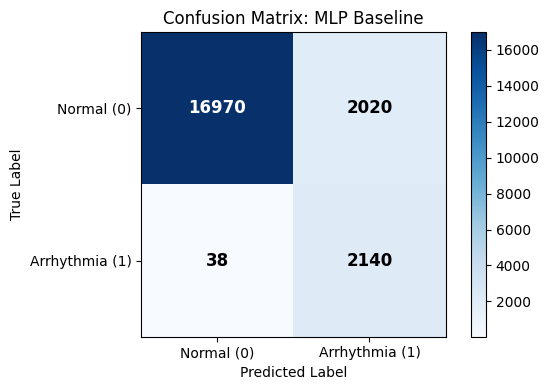

In [7]:
# CELL 5: CLASSICAL BASELINE (MLP)
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report
import numpy as np
import torch

class BaselineMLP(nn.Module):
    def __init__(self, input_size=300):
        super(BaselineMLP, self).__init__()
        self.flatten = nn.Flatten() # Flattens (Batch, 1, 300) to (Batch, 300)
        
        # Simple feed-forward network (No spatial or temporal awareness)
        self.fc1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, 1) # Output 1 logit for BCE loss
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        out = self.fc2(x)
        return out

baseline_model = BaselineMLP().to(device)
print("Baseline Architecture Initialization Complete.\n")

# --- FAIR COMPARISON: USE THE EXACT SAME LOSS & WEIGHT ---
num_normal = (y_train_tensor == 0).sum().item()
num_arrhythmia = (y_train_tensor == 1).sum().item()
pos_weight_val = num_normal / num_arrhythmia
baseline_pos_weight = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)

baseline_criterion = nn.BCEWithLogitsLoss(pos_weight=baseline_pos_weight)
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

# --- TRAINING BASELINE ---
print(f"--- Training Baseline MLP (5 Epochs) | pos_weight={pos_weight_val:.2f} ---")

for epoch in range(1, 6):
    baseline_model.train()
    train_loss, train_correct, train_count = 0.0, 0, 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        baseline_optimizer.zero_grad()
        
        logits = baseline_model(xb)
        loss_out = baseline_criterion(logits, yb)
        loss_out.backward()
        baseline_optimizer.step()
        
        batch_size = xb.size(0)
        train_loss += loss_out.item() * batch_size
        preds = (torch.sigmoid(logits) > 0.5).float()
        train_correct += (preds == yb).sum().item()
        train_count += batch_size
        
    train_loss /= train_count
    train_acc = train_correct / train_count
    
    # Validation Check
    baseline_model.eval()
    val_loss, val_correct, val_count = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = baseline_model(xb)
            loss_out = baseline_criterion(logits, yb)
            
            batch_size = xb.size(0)
            val_loss += loss_out.item() * batch_size
            preds = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_count += batch_size
            
    val_loss /= val_count
    val_acc = val_correct / val_count
    
    print(
        f"Epoch {epoch} | train_loss= {train_loss:.4f} acc= {train_acc:.4f} | "
        f"val_loss= {val_loss:.4f} acc= {val_acc:.4f}"
    )

# --- EVALUATING BASELINE ---
print("\n--- Final Evaluating Baseline MLP ---")
baseline_model.eval()
base_preds, base_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = baseline_model(xb.to(device))
        preds = (torch.sigmoid(logits) > 0.5).float()
        
        base_preds.extend(preds.cpu().numpy())
        base_true.extend(yb.numpy())

base_preds = np.array(base_preds).flatten()
base_true = np.array(base_true).flatten()

print("\nBaseline Classification Report:")
print(classification_report(base_true, base_preds, target_names=['Normal (0)', 'Arrhythmia (1)']))

# --- PLOTING THE CONFUSION MATRIX ---
plot_beautiful_cm(base_true, base_preds, "MLP Baseline", cmap=plt.cm.Blues)

In [8]:
# CELL 6: HYBRID CNN-BiLSTM & HYPERPARAMETER TUNING
import torch
import torch.nn as nn
import torch.optim as optim
import random

# --- 1. CONFIGURABLE HYBRID ARCHITECTURE ---
class Tunable_Hybrid_CNN_BiLSTM(nn.Module):
    def __init__(self, hidden_size=64, drop=0.4, n_fc1=128):
        super(Tunable_Hybrid_CNN_BiLSTM, self).__init__()
        
        # Spatial Feature Extraction
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3, stride=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2, stride=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(drop / 2)
        )
        
        # Temporal Sequence Modeling
        self.bilstm = nn.LSTM(
            input_size=32, 
            hidden_size=hidden_size, 
            batch_first=True,
            bidirectional=True 
        )
        
        # Classification Head
        self.dropout = nn.Dropout(drop)
        self.fc1 = nn.Linear(hidden_size * 2, n_fc1)
        self.bn = nn.BatchNorm1d(n_fc1) # Post-activation batch norm
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_fc1, 1) # Output 1 logit for BCE
        
    def forward(self, x):
        x = self.cnn(x) 
        x = x.permute(0, 2, 1) 
        out, _ = self.bilstm(x)
        out = self.dropout(out[:, -1, :]) 
        out = self.relu(self.fc1(out))
        out = self.bn(out) 
        out = self.fc2(out)
        return out

# --- 2.TRAINING LOOP ---
def train_rnn(model, patience):
    num_normal = (y_train_tensor == 0).sum().item()
    num_arrhythmia = (y_train_tensor == 1).sum().item()
    pos_weight = torch.tensor([num_normal / num_arrhythmia], dtype=torch.float32).to(device)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
    
    epochs = 25 
    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_left = patience
    best_state = None
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_correct, train_count = 0.0, 0, 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            
            if scaler:
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    logits = model(xb)
                    loss_out = criterion(logits, yb)
                scaler.scale(loss_out).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(xb)
                loss_out = criterion(logits, yb)
                loss_out.backward()
                optimizer.step()
                
            batch_size = xb.size(0)
            train_loss += loss_out.item() * batch_size
            preds = (torch.sigmoid(logits) > 0.5).float()
            train_correct += (preds == yb).sum().item()
            train_count += batch_size
                
        train_loss /= train_count
        train_acc = train_correct / train_count
        
        model.eval()
        val_loss, val_correct, val_count = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                
                if scaler:
                    with torch.autocast(device_type='cuda', dtype=torch.float16):
                        logits = model(xb)
                        loss_out = criterion(logits, yb)
                else:
                    logits = model(xb)
                    loss_out = criterion(logits, yb)
                
                batch_size = xb.size(0)
                val_loss += loss_out.item() * batch_size
                preds = (torch.sigmoid(logits) > 0.5).float()
                val_correct += (preds == yb).sum().item()
                val_count += batch_size
                
        val_loss /= val_count
        val_acc = val_correct / val_count
        
        print(f"  Epoch {epoch} | train_loss= {train_loss:.4f} acc= {train_acc:.4f} | "
              f"val_loss= {val_loss:.4f} acc= {val_acc:.4f}")
        
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left == 0: 
                print("  -> Early stopping triggered!")
                break
                
    return best_val_acc, best_state

# --- 3. RANDOM SEARCH TUNING ---
hidden_size_list = [32, 64]
drop_list = [0.2, 0.3, 0.4]
feat_list = [64, 128]
patience_list = [3, 5]

n_trials = 5
acc_res = {}
best_overall_acc = 0.0
best_overall_state = None
best_params = None

print(f"--- Starting Random Search ({n_trials} Trials) ---")

for trial in range(n_trials):
    h = random.choice(hidden_size_list)
    drop = random.choice(drop_list)
    feat = random.choice(feat_list)
    patience = random.choice(patience_list)
    
    print(f"\nTrial {trial+1}/{n_trials} -> h: {h}, drop: {drop}, feat: {feat}, patience: {patience}")
    
    model = Tunable_Hybrid_CNN_BiLSTM(hidden_size=h, drop=drop, n_fc1=feat).to(device)
    acc, state = train_rnn(model, patience)
    acc_res[(h, drop, feat, patience)] = acc
    
    if acc > best_overall_acc:
        best_overall_acc = acc
        best_overall_state = state
        best_params = (h, drop, feat, patience)

print("\n--- Hyperparameter Search Complete ---")
print(f"Best Configuration Found (h, drop, feat, patience): {best_params}")
print(f"Best Validation Accuracy: {best_overall_acc:.4f}")

# Lock in the final model with the absolute best weights
final_model = Tunable_Hybrid_CNN_BiLSTM(hidden_size=best_params[0], drop=best_params[1], n_fc1=best_params[2]).to(device)
final_model.load_state_dict(best_overall_state)

--- Starting Random Search (5 Trials) ---

Trial 1/5 -> h: 32, drop: 0.2, feat: 128, patience: 3
  Epoch 1 | train_loss= 0.2651 acc= 0.9170 | val_loss= 0.5366 acc= 0.8528
  Epoch 2 | train_loss= 0.0597 acc= 0.9876 | val_loss= 0.6396 acc= 0.8659
  Epoch 3 | train_loss= 0.0384 acc= 0.9920 | val_loss= 0.2599 acc= 0.9331
  Epoch 4 | train_loss= 0.0342 acc= 0.9930 | val_loss= 0.4788 acc= 0.8720
  Epoch 5 | train_loss= 0.0290 acc= 0.9940 | val_loss= 0.5374 acc= 0.8762
  Epoch 6 | train_loss= 0.0269 acc= 0.9947 | val_loss= 0.7706 acc= 0.7867
  -> Early stopping triggered!

Trial 2/5 -> h: 32, drop: 0.2, feat: 64, patience: 3
  Epoch 1 | train_loss= 0.2521 acc= 0.9189 | val_loss= 0.3147 acc= 0.9033
  Epoch 2 | train_loss= 0.0628 acc= 0.9865 | val_loss= 0.2989 acc= 0.9160
  Epoch 3 | train_loss= 0.0485 acc= 0.9898 | val_loss= 0.3258 acc= 0.9003
  Epoch 4 | train_loss= 0.0331 acc= 0.9932 | val_loss= 0.4050 acc= 0.9047
  Epoch 5 | train_loss= 0.0299 acc= 0.9936 | val_loss= 0.4700 acc= 0.8714
  ->

<All keys matched successfully>

--- Running Final Evaluation on Unseen Test Patients (Best Tuned Model) ---

Final Classification Report (Tuned Hybrid CNN-BiLSTM):
                precision    recall  f1-score   support

    Normal (0)       1.00      0.93      0.96     18990
Arrhythmia (1)       0.61      0.96      0.75      2178

      accuracy                           0.93     21168
     macro avg       0.80      0.95      0.85     21168
  weighted avg       0.96      0.93      0.94     21168



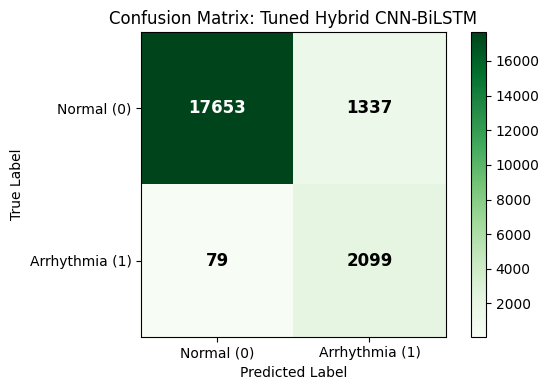

In [9]:
# CELL 7: FINAL EVALUATION & CONFUSION MATRIX
from sklearn.metrics import classification_report
import numpy as np
import torch

print("--- Running Final Evaluation on Unseen Test Patients (Best Tuned Model) ---")

# Evaluate using the final_model from our random search
final_model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        
        # Forward pass
        logits = final_model(xb)
        
        # Convert logits to probabilities, then to binary predictions (0 or 1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        
        # Store predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(yb.numpy())

# Flatten arrays for scikit-learn metrics
all_preds = np.array(all_preds).flatten()
all_true = np.array(all_true).flatten()

# --- 1. Classification Report ---
print("\nFinal Classification Report (Tuned Hybrid CNN-BiLSTM):")
print(classification_report(all_true, all_preds, target_names=['Normal (0)', 'Arrhythmia (1)']))

# --- 2. Confusion Matrix ---
# Using the reusable function we defined in Cell 4 for consistent styling across all matrices
plot_beautiful_cm(all_true, all_preds, "Tuned Hybrid CNN-BiLSTM", cmap=plt.cm.Greens)

--- Generating ROC Curves ---


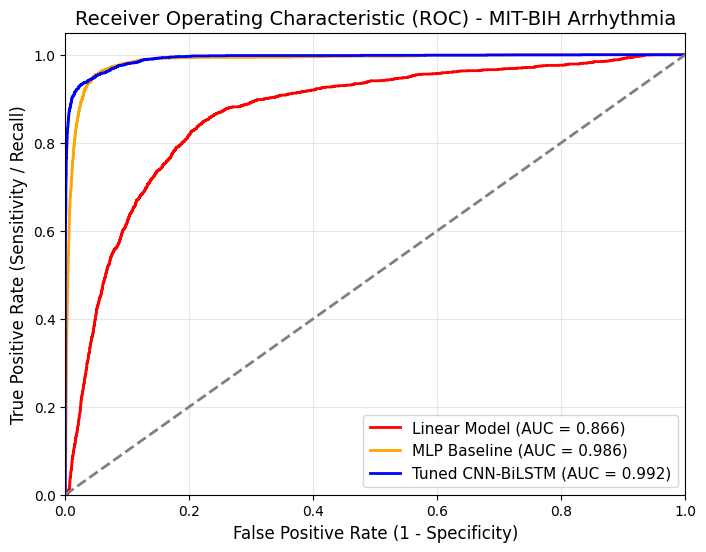

In [10]:
# CELL 8: ROC / AUC COMPARISON
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd
import torch

print("--- Generating ROC Curves ---")

def get_probabilities(model, dataloader):
    model.eval()
    all_probs = []
    all_targets = []
    with torch.no_grad():
        for xb, yb in dataloader:
            logits = model(xb.to(device))
            probs = torch.sigmoid(logits) # Get pure probability (0.0 to 1.0)
            all_probs.extend(probs.cpu().numpy())
            all_targets.extend(yb.numpy())
    return np.array(all_probs).flatten(), np.array(all_targets).flatten()

# Get probabilities for all 3 models
lin_probs, y_true_roc = get_probabilities(linear_model, test_loader)
mlp_probs, _ = get_probabilities(baseline_model, test_loader)
cnn_probs, _ = get_probabilities(final_model, test_loader)

# Calculate False Positive Rate, True Positive Rate, and Area Under Curve
fpr_lin, tpr_lin, _ = roc_curve(y_true_roc, lin_probs)
roc_auc_lin = auc(fpr_lin, tpr_lin)

fpr_mlp, tpr_mlp, _ = roc_curve(y_true_roc, mlp_probs)
roc_auc_mlp = auc(fpr_mlp, tpr_mlp)

fpr_cnn, tpr_cnn, _ = roc_curve(y_true_roc, cnn_probs)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_lin, tpr_lin, color='red', lw=2, label=f'Linear Model (AUC = {roc_auc_lin:.3f})')
plt.plot(fpr_mlp, tpr_mlp, color='orange', lw=2, label=f'MLP Baseline (AUC = {roc_auc_mlp:.3f})')
plt.plot(fpr_cnn, tpr_cnn, color='blue', lw=2, label=f'Tuned CNN-BiLSTM (AUC = {roc_auc_cnn:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--') # Random guess line

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) - MIT-BIH Arrhythmia', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [11]:
# CELL 9: PERFORMANCE COMPARISON TABLE
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("--- Final Model Comparison ---")

def get_metrics(y_true, y_probs):
    y_pred = (y_probs > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    # Get metrics specifically for the Arrhythmia class (Class 1)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[1], zero_division=0)
    return round(acc*100, 2), round(prec[0], 2), round(rec[0], 2), round(f1[0], 2)

metrics_lin = get_metrics(y_true_roc, lin_probs)
metrics_mlp = get_metrics(y_true_roc, mlp_probs)
metrics_cnn = get_metrics(y_true_roc, cnn_probs)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Linear)', 'MLP Baseline (Flat)', 'Tuned CNN-BiLSTM (Deep Sequence)'],
    'Overall Accuracy (%)': [metrics_lin[0], metrics_mlp[0], metrics_cnn[0]],
    'Arrhythmia Precision': [metrics_lin[1], metrics_mlp[1], metrics_cnn[1]],
    'Arrhythmia Recall': [metrics_lin[2], metrics_mlp[2], metrics_cnn[2]],
    'Arrhythmia F1-Score': [metrics_lin[3], metrics_mlp[3], metrics_cnn[3]]
})

# Displazing the table cleanly
display(comparison_df)

--- Final Model Comparison ---


,Model,Overall Accuracy (%),Arrhythmia Precision,Arrhythmia Recall,Arrhythmia F1-Score
0,Logistic Regression (Linear),75.25,0.28,0.88,0.42
1,MLP Baseline (Flat),90.28,0.51,0.98,0.68
2,Tuned CNN-BiLSTM (Deep Sequence),93.31,0.61,0.96,0.75


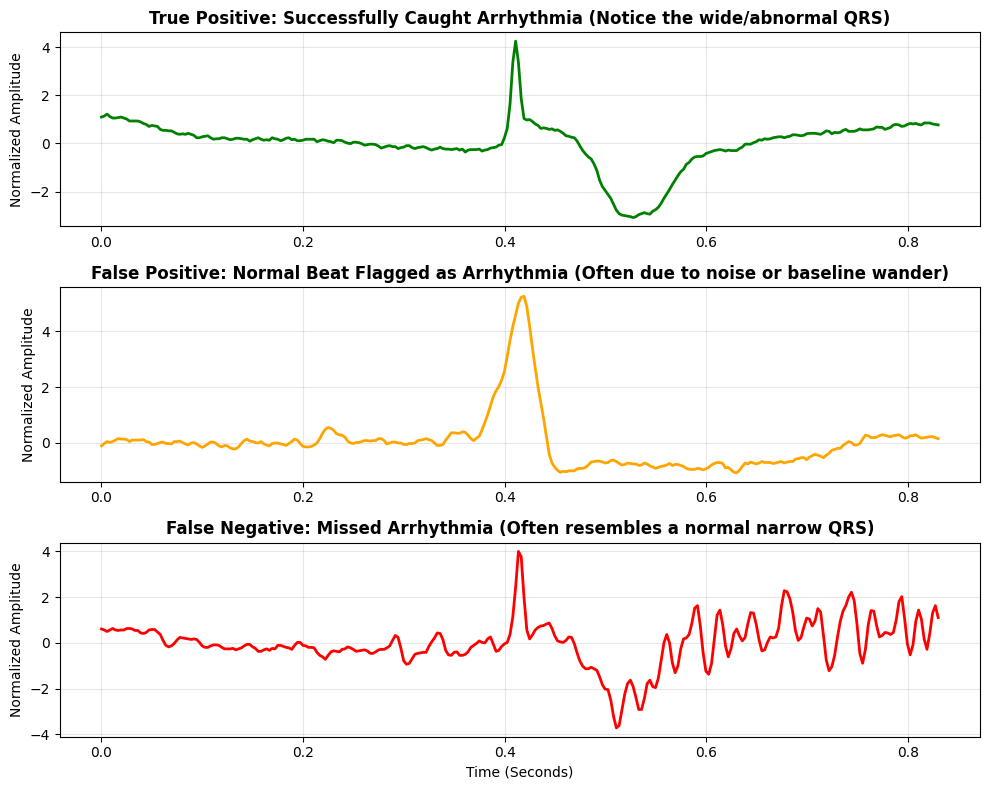

In [12]:
# CELL 10: PHYSIOLOGICAL MISCLASSIFICATION ANALYSIS
import matplotlib.pyplot as plt
import numpy as np

# Finding indices of specific predictions
preds_cnn = (cnn_probs > 0.5).astype(int)

# 1. True Positive (Correctly identified Arrhythmia)
tp_indices = np.where((y_true_roc == 1) & (preds_cnn == 1))[0]
# 2. False Positive (Healthy beat falsely flagged as Arrhythmia)
fp_indices = np.where((y_true_roc == 0) & (preds_cnn == 1))[0]
# 3. False Negative (Arrhythmia missed by the model)
fn_indices = np.where((y_true_roc == 1) & (preds_cnn == 0))[0]

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
time_axis = np.linspace(0, 0.83, 300) # 300 samples at 360Hz is ~0.83 seconds

def plot_ecg(ax, index_list, title, color):
    if len(index_list) > 0:
        idx = index_list[0] # Grabing the first example
        # X_test was flattened to (N, 1, 300) in the dataloader, grabing the raw test array
        signal = X_test[idx] 
        ax.plot(time_axis, signal, color=color, lw=2)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel("Normalized Amplitude")
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No examples found", ha='center', va='center')

# Ploting them
plot_ecg(axes[0], tp_indices, "True Positive: Successfully Caught Arrhythmia (Notice the wide/abnormal QRS)", "green")
plot_ecg(axes[1], fp_indices, "False Positive: Normal Beat Flagged as Arrhythmia (Often due to noise or baseline wander)", "orange")
plot_ecg(axes[2], fn_indices, "False Negative: Missed Arrhythmia (Often resembles a normal narrow QRS)", "red")

axes[2].set_xlabel("Time (Seconds)")
fig.tight_layout()
plt.show()